<a href="https://colab.research.google.com/github/hassan1662n/Iris_prediction/blob/main/iris_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
df = X.copy()
df['target'] = y

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Text(0, 0.5, 'count')

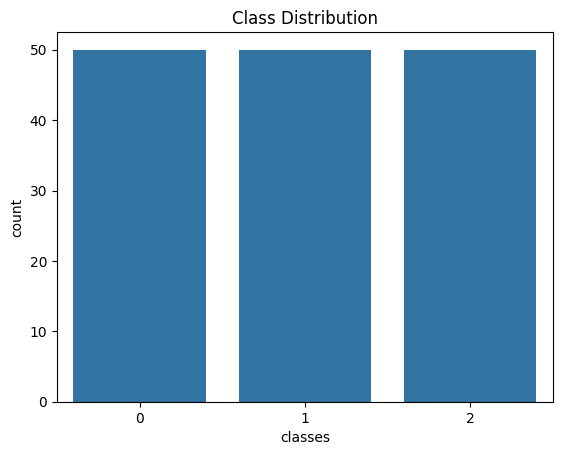

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x= df["target"])
plt.title("Class Distribution")
plt.xlabel("classes")
plt.ylabel("count")

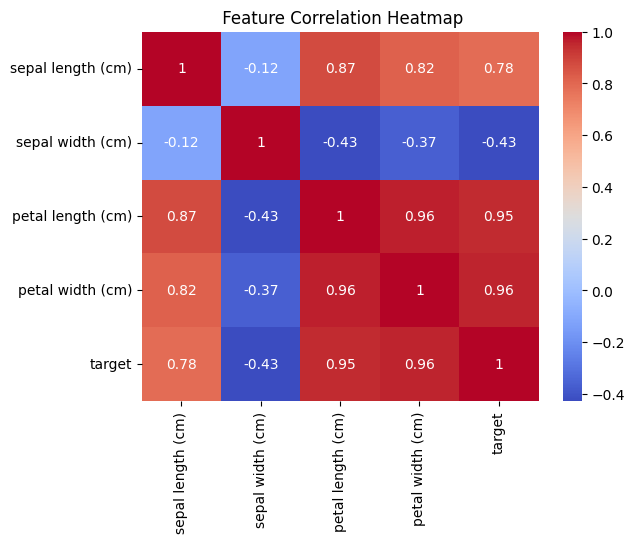

In [5]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title(" Feature Correlation Heatmap")
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

In [9]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)
y_pred_tree = tree.predict(x_test)

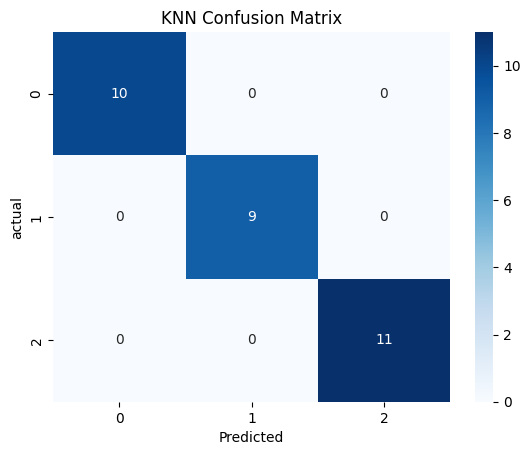

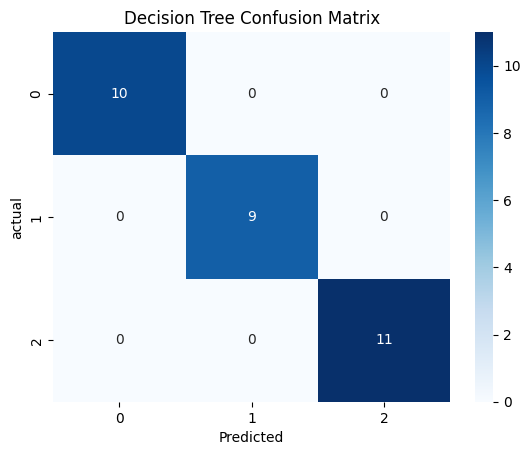

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('actual')
    plt.show()

plot_confusion(y_test, y_pred_knn, "KNN Confusion Matrix")
plot_confusion(y_test, y_pred_tree, "Decision Tree Confusion Matrix")

In [11]:
print(classification_report(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

